# Creating a Lightcurve from a Pre-Made TESS TPF in MAST
## Author
Aidan Niklaus

## Learning Goals
- Become familiar with Lightkurve basics
- Become familiar with the Mikulski Archive for Space Telescopes (MAST)
- Search for and download pre-made TESS Target Pixel Files (TPF) and/or TESS Full Frame Images (FFI) from MAST
- Create and plot a Lightcurve from a pre-made TPF using aperture masking

## Keywords
TESS, MAST, TPF, Lightcurve, aperture masking

## Summary
This tutorial will demonstrate how to utilize the Python package Lightkurve in tandem with MAST to create a lightcurve using a pre-made TESS TPF.

## Imports

In [29]:
import lightkurve as lk

# Makes plots appear directly after respective code block
%matplotlib inline

## Step 1: Search for and Download the TPF
In the previous tutorial, we left off by searching MAST for pre-made TPFs of the star with identification TIC 180567608.

In [2]:
# target : the name or identifying number of your star
search_result = lk.search_targetpixelfile(target="TIC 180567608")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 22,2020,TESS-SPOC,1800,180567608,0.0
1,TESS Sector 23,2020,TESS-SPOC,1800,180567608,0.0
2,TESS Sector 49,2022,TESS-SPOC,600,180567608,0.0
3,TESS Sector 76,2024,TESS-SPOC,200,180567608,0.0


In order to actually use the data, we must download it. Downloading files from MAST is the most computationally expensive aspect of creating a lightcurve, so don't worry if it takes your computer a little while to execute this task. To help alleviate this stress, astronomers often download the TPF for each sector individually. For this example, let's download the first sector available (0th index).

In [3]:
tpf = search_result[0].download()

It is always good practice to get visual confirmation of the data we are working with. Let's plot the TPF we just downloaded to check it out.

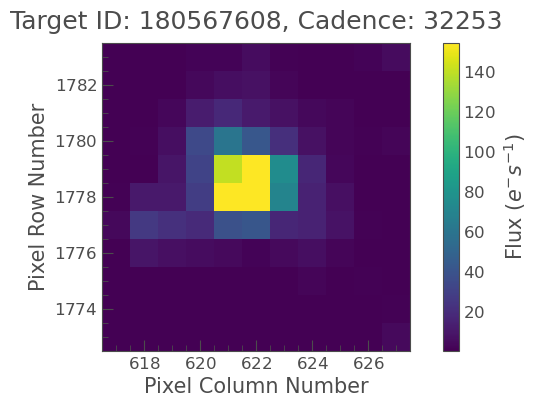

In [5]:
tpf.plot();

Cool! As you can see, the high-flux, yellow parts of the graph are our star, with the dimmer parts being the background. Despite this distinction being very obvious to our eyes, our program still doesn't know what parts of the TPF to graph. To solve this, we can use a method called aperture masking to define to Lightkurve what is and isn't our star.

In [26]:
# Higher thresholds are more selective as they increase the "passing" value for pixels
target_mask = tpf.create_threshold_mask(threshold=25, reference_pixel='center')

Aperture masking works by only grabbing pixels that surpass a certain threshold. Let's check that the threshold we set is accurate by graphing our TPF again, but this time with the aperture mask over it.

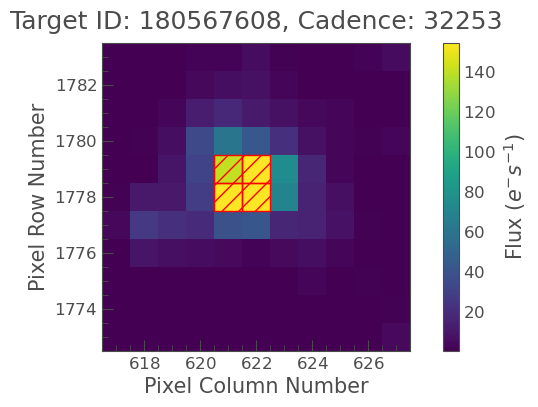

In [27]:
tpf.plot(aperture_mask=target_mask);

Great! Now our computer can see what our eyes see! Let's now use our TPF along with that mask to make our light curve.

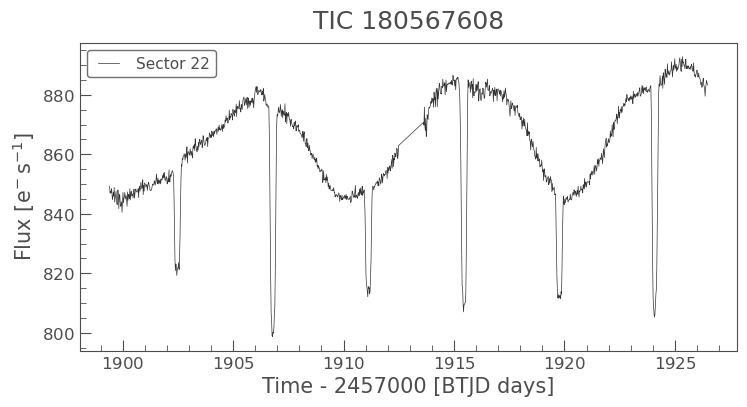

In [28]:
# Making sure to let Lightkurve know that we just want to use the pixels within our mask to make our lightcurve
lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Plotting our lightcurve to see what we got!
lc.plot(title="TIC 180567608", label="Sector 22");

Now that's a beautiful lightcurve! Great job!

Lightcurves can help tell us a lot about the nature of stars as they show us the amount of light they emit over time. For example, the periodic dips in flux for TIC 180567608 are quintessential of an Eclipsing Binary---very cool!

To recap, our workflow was as follows:
1. search MAST for readily available TPFs of our star
2. download one TPF to work with
3. make an aperture mask that captures only the pixels representing our star
4. make a lightcurve using our TPF and mask